# Predicción de la duración de estancia hospitalaria

**Proyecto**: Fundamentos de Ciencia de Datos 2025-2  
**Autor**: Thomas GIRAULT  

---

## Contexto

Hoy en día los hospitales enfrentan un gran reto: saber con antelación cuánto tiempo ocupará cada paciente una cama. Predecir la duración de la estancia no solo ayuda a mejorar la atención, sino también a organizar los recursos, reducir esperas y evitar sobrecargas en épocas de alta demanda.  

En este proyecto vamos a intentar estimar la duración de la hospitalización de un paciente a partir de información básica: sexo, índice de masa corporal (IMC), historial médico, número de ingresos previos y varios datos clínicos como indicadores de laboratorio. La idea es construir un modelo que pueda apoyar la **planificación hospitalaria** y la **gestión de camas disponibles**.  

---

## Dataset

Trabajaremos con el dataset **“Hospital Length of Stay”** publicado por Microsoft en Kaggle:  
https://www.kaggle.com/datasets/aayushchou/hospital-length-of-stay-dataset-microsoft  

En el repositorio se incluirán los datos originales (tal cual descargados) y también una versión filtrada y adaptada para nuestro análisis.  

---

## Objetivos

- Explorar y entender los datos para identificar las variables más útiles.  
- Hacer un análisis descriptivo con estadísticas y visualizaciones (distribuciones, relaciones entre variables, etc.).  
- Detectar valores atípicos y decidir si se eliminan o si tienen sentido clínico.  
- Preparar una base sólida para la siguiente fase, donde se entrenará un modelo de predicción de la duración de la estancia.  

---

## Dependencias y librerías

El análisis se hará principalmente con:  
- `numpy` y `pandas` para manipulación de datos,  
- `matplotlib` y `seaborn` para visualización,  
- opcionalmente `scipy` u otras librerías si hacen falta para estadística o detección de outliers.  

Instalación rápida:  

In [2]:
!pip install numpy pandas matplotlib seaborn scipy

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# I - La elección de las variables características

La primera etapa de mi proyecto fue filtrar este enorme dataset, que contiene 100k muestras y un total de 28 características. Son precisamente estas características las que nos interesan en esta fase. En efecto, ¿cómo podemos juzgar si una variable es pertinente para conservar, utilizar en nuestro estudio o incluso para construir nuevas variables?

Al final de esta etapa, debo conservar como mínimo 6 características, de las cuales 3 continuas y 3 discretas.

## Presentación de las variables en su globalidad

Antes de explicar las variables que he elegido, voy a presentar rápidamente el conjunto de variables disponibles en el dataset. Hay un total de 28. Aquí está la lista completa:  

<p align="center">
    <img src="../datos/data_explained.png" alt="Explicación de los datos" width="900">
</p>

Encontramos, por ejemplo, el **ID**, la **fecha de ingreso** y la **fecha de alta**, que como era de esperar, no serán útiles para nuestro estudio.  

En cambio, varios grupos de variables resultan más interesantes:  

- **Índice 5 a 15: comorbilidades ICD-9**  
  Son variables binarias (1 = presencia de la comorbilidad, 0 = ausencia).  
  Son particularmente relevantes, ya que el ICD es un estándar médico ampliamente utilizado en la codificación de diagnósticos. Estas comorbilidades se sabe que tienen un impacto directo en la duración de la estancia.  

- **Índice 16 a 21: medidas sanguíneas**  
  Aquí encontramos variables continuas como el hematocrito, la creatinina o el sodio.  
  Estos indicadores biológicos son interesantes porque permiten detectar anomalías en la sangre y reflejan el estado de salud del paciente.  

- **Medidas fisiológicas**  
  También disponemos del **IMC (BMI)**, del **pulso** y de la **frecuencia respiratoria**, tres variables clásicas en el seguimiento clínico.  

- **Comorbilidades no-ICD**  
  Finalmente, una variable adicional indica el número de comorbilidades no referenciadas en el ICD. Es un entero que va de 0 a 10.  

Frente a tal cantidad de información, es difícil saber en qué concentrar la atención. Los datos sanguíneos, por ejemplo, son muy interesantes, pero ya ocupan seis variables, lo que no dejaría espacio para otras dimensiones.  
Nuestro profesor nos aconsejó entonces revisar la literatura científica. Le dediqué un día entero y aquí está el resumen de mis hallazgos.

## Lo que dice la literatura

Según [esta tesis](https://theses.hal.science/tel-04053390/document), las características más importantes para predecir la duración de la estancia son:  
- la edad,  
- los diagnósticos principales y secundarios (es decir, las comorbilidades),  
- el tipo de admisión,  
- y finalmente la evolución del paciente durante la estancia.  

En mi dataset no dispongo de toda esta información, sino únicamente del número de diagnósticos principales y secundarios. Por lo tanto, decidí sumar las comorbilidades de los índices 5 a 15 para crear un puntaje global basado en el ICD-9. También conservé la variable que corresponde al número de comorbilidades secundarias no codificadas en ICD como segunda característica discreta. De hecho, vi en Kaggle que varios recomendaban fuertemente este enfoque y que daba buenos resultados en los modelos.

Después decidí conservar el **IMC (BMI)**, ya que la literatura muestra una fuerte asociación con la duración de la estancia hospitalaria. Los pacientes con obesidad severa o, por el contrario, desnutridos (IMC bajo) suelen tener estancias más largas. Varios estudios (cirugía cardíaca, ortopedia, cuidados intensivos) confirman una relación en forma de U: un IMC demasiado bajo o demasiado alto está relacionado con una hospitalización prolongada. Aquí algunas referencias:  

- [Nutrition support in critically ill patients](https://aspenjournals.onlinelibrary.wiley.com/doi/10.1177/088453360001500405)  
- [Obesity and postoperative complications in cardiac surgery](https://pubmed.ncbi.nlm.nih.gov/15681111/)  
- [Impact of body mass index on hospital stay in intensive care patients](https://pubmed.ncbi.nlm.nih.gov/30685103/)  

De la misma manera, decidí conservar la **frecuencia respiratoria**, que es un indicador clínico reconocido y ampliamente utilizado para predecir la severidad de los casos y, por ende, la duración de la estancia.

En cambio, el **pulso** me sorprendió. Según mis investigaciones, parece tener mucho menos impacto en la duración de la estancia. Un ritmo cardíaco normal en reposo varía entre 60 y 100 bpm, y existen variaciones fisiológicas naturales según los individuos (algunos laten a 50, otros a 90). Esto no necesariamente aporta información relevante para la duración de la hospitalización. Además, no encontré ningún estudio sólido que lo utilice como predictor directo, por lo que decidí descartarlo.

Por otra parte, añadí la variable **rcount**, que cuenta el número de veces que un paciente ha sido readmitido en los últimos 180 días. Este valor va de 0 a 5+, lo cual no es muy preciso (un paciente 5+ puede haber vuelto 5 veces o 15 veces). Pero en Estados Unidos, las restricciones de confidencialidad impiden dar un valor exacto superior a 5, ya que esto podría hacer identificables a ciertos pacientes.

Finalmente, elegí añadir el **género** del paciente, que es una variable categórica y que posteriormente transformaré en una variable discreta.  

## El caso de las variables sanguíneas

Según la literatura, las dos variables biológicas más utilizadas para predecir la duración de la estancia son las relacionadas con la función renal: la **creatinina** y el **BUN (blood urea nitrogen)**. Se consideran buenos indicadores en cuidados intensivos, ya que reflejan directamente el estado de la función renal, estrechamente ligada a la gravedad y, por ende, a la duración de la estancia. Estas variables parecen más relevantes que otras como la glucosa o el sodio, por ejemplo.

## Resumen de las variables elegidas

| Variable                        | Tipo       | Definición                                         |
|---------------------------------|------------|----------------------------------------------------|
| IMC (BMI)                       | Continua   | Índice de masa corporal                            |
| Frecuencia respiratoria         | Continua   | Número de respiraciones por minuto                 |
| Creatinina                      | Continua   | Valor medio de creatinina (mg/dL)                  |
| Blood Urea Nitrogen (BUN)       | Continua   | Nivel de urea en sangre, indicador de función renal|
| Género                          | Discreta   | Sexo del paciente (M/F)                            |
| Recuento de readmisiones (Rcount)| Discreta  | Número de readmisiones (0 a 5+)                    |
| Comorbilidades ICD-9 (suma)     | Discreta   | Número de comorbilidades principales ICD-9         |
| Diagnósticos secundarios ICD-9  | Discreta   | Número de diagnósticos secundarios codificados ICD-9|

### Variable objetivo

| Variable   | Tipo  | Definición                              |
|------------|-------|-----------------------------------------|
| LOS        | Objetivo | Duración de la estancia hospitalaria (días) |


# II - Creación del nuevo dataset y modificaciones

Dado el tamaño considerable del dataset (100K muestras y 28 características), la mejor manera de generar un conjunto de datos más ligero y limpio es automatizar el proceso mediante un script.  
Por ello, desarrollé un script que extrae únicamente las variables relevantes, limpia los datos y, cuando es necesario, crea nuevas variables derivadas.  
De esta forma, obtuve un dataset más claro, manejable y perfectamente adaptado para el resto del análisis.


In [4]:
# archivos
input_file = "../datos/LengthOfStay.csv"
output_file = "../datos/LengthOfStay_filtered.csv"

# columnas que queremos guardar
cols_to_keep = [
    "rcount", 
    "gender",
    "bloodureanitro",
    "creatinine", 
    "bmi", 
    "respiration", 
    "secondarydiagnosisnonicd9", 
    "lengthofstay"
]

# columnas icd-9 principales
icd9_cols = [
    "dialysisrenalendstage","asthma","irondef","pneum","substancedependence",
    "psychologicaldisordermajor","depress","psychother","fibrosisandother",
    "malnutrition","hemo"
]

# si el archivo filtrado no existe lo creamos
if not os.path.exists(output_file):
    df = pd.read_csv(input_file)
    df["icd9_comorbidity_sum"] = df[icd9_cols].sum(axis=1)
    df_filtered = df[cols_to_keep + ["icd9_comorbidity_sum"]]
    df_filtered.to_csv(output_file, index=False)
    print(f"guardado como {output_file}")
else:
    print("el archivo filtrado ya existe, cargando...")
    df_filtered = pd.read_csv(output_file)

print("\nInformación general:")
df_filtered.info()

# mostrar estadisticas basicas
print("\nresumen estadistico del dataset filtrado:\n")
display(df_filtered.describe(include="all"))

# mostrar primeras filas
print("\nprimeras filas del dataset filtrado:\n")
display(df_filtered.head())

print("\nValores nulos por columna:")
print(df_filtered.isnull().sum())

el archivo filtrado ya existe, cargando...

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   rcount                     100000 non-null  object 
 1   gender                     100000 non-null  object 
 2   bloodureanitro             100000 non-null  float64
 3   creatinine                 100000 non-null  float64
 4   bmi                        100000 non-null  float64
 5   respiration                100000 non-null  float64
 6   secondarydiagnosisnonicd9  100000 non-null  int64  
 7   lengthofstay               100000 non-null  int64  
 8   icd9_comorbidity_sum       100000 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 6.9+ MB

resumen estadistico del dataset filtrado:



,rcount,gender,bloodureanitro,creatinine,bmi,respiration,secondarydiagnosisnonicd9,lengthofstay,icd9_comorbidity_sum
count,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
unique,6,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,55031,57643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,14.097185,1.099350,29.805759,6.493768,2.123310,4.00103,0.743500
std,NaN,NaN,12.952454,0.200262,2.003769,0.568473,2.050641,2.36031,1.097406
min,NaN,NaN,1.000000,0.219770,21.992683,0.200000,0.000000,1.00000,0.000000
25%,NaN,NaN,11.000000,0.964720,28.454235,6.500000,1.000000,2.00000,0.000000
50%,NaN,NaN,12.000000,1.098764,29.807516,6.500000,1.000000,4.00000,0.000000
75%,NaN,NaN,14.000000,1.234867,31.156885,6.500000,3.000000,6.00000,1.000000



primeras filas del dataset filtrado:



,rcount,gender,bloodureanitro,creatinine,bmi,respiration,secondarydiagnosisnonicd9,lengthofstay,icd9_comorbidity_sum
0,0,F,12.0,1.390722,30.432418,6.5,4,3,0
1,5+,F,8.0,0.943164,28.460516,6.5,1,7,0
2,1,F,12.0,1.065750,28.843812,6.5,2,3,0
3,0,F,12.0,0.906862,27.959007,6.5,1,1,0
4,0,F,11.5,1.242854,30.258927,5.6,2,4,2



Valores nulos por columna:
rcount                       0
gender                       0
bloodureanitro               0
creatinine                   0
bmi                          0
respiration                  0
secondarydiagnosisnonicd9    0
lengthofstay                 0
icd9_comorbidity_sum         0
dtype: int64


# III - Análisis y exploración de los datos

En esta sección realizaremos un primer análisis exploratorio de las variables incluidas en nuestro nuevo dataset.  
El objetivo es obtener una visión global de la estructura de los datos mediante diferentes herramientas: histogramas, boxplots, matrices de correlación, entre otras.  
Estas visualizaciones permitirán comprender mejor la distribución de las variables, identificar posibles relaciones entre ellas y detectar la presencia de valores atípicos.  


Dividiremos esta parte en tres secciones principales:

- **A. Univariadas:** Exploración individual de cada variable, analizando su distribución y principales estadísticas descriptivas (media, mediana, moda, varianza, etc.).
- **B. Bivariadas:** Análisis de las relaciones entre pares de variables, mediante gráficos de dispersión, boxplots y correlaciones.
- **C. Multivariadas:** Estudio conjunto de varias variables, utilizando herramientas como pairplots y análisis de componentes principales (PCA) para visualizar la estructura global y posibles agrupamientos en los datos.

Esta estructura nos permitirá caracterizar de manera completa la información disponible y sentar las bases para los análisis predictivos posteriores.


## III.A - Univariadas

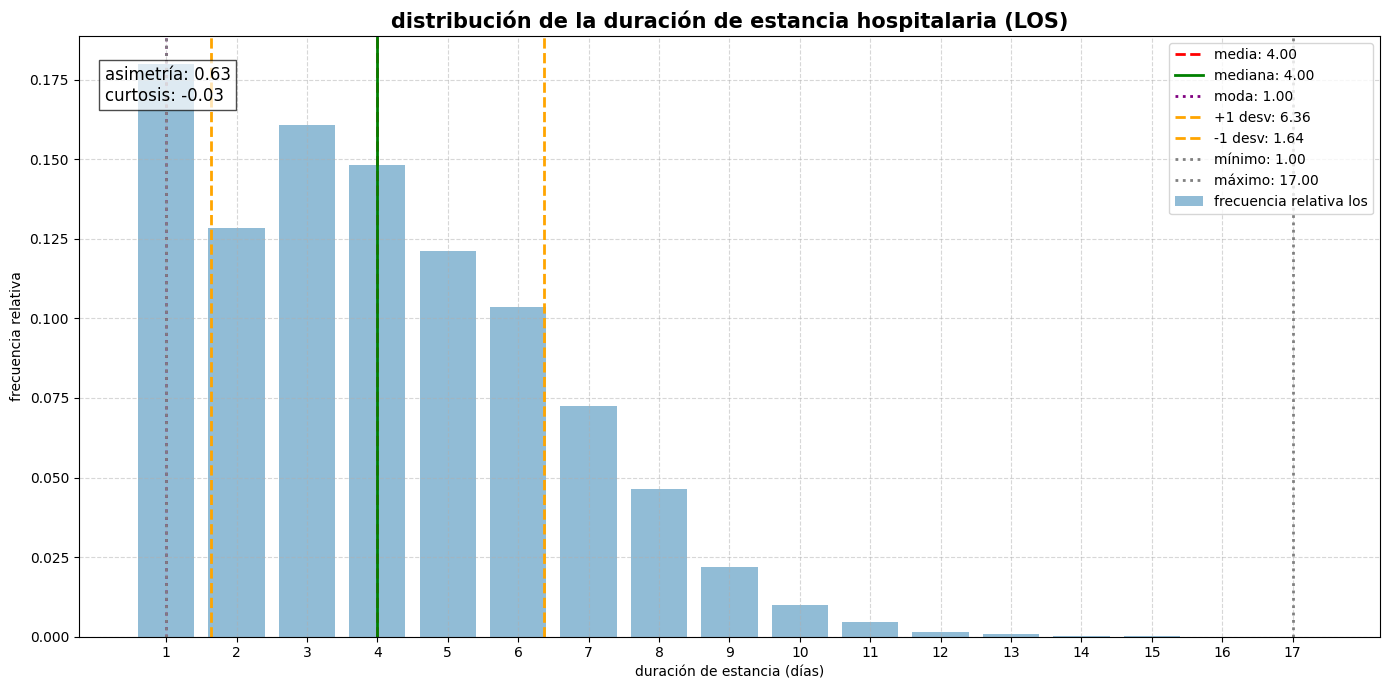

Media: 4.00
Mediana: 4.00
Moda: 1.00
Mínimo: 1.00
Máximo: 17.00
Desviación estándar: 2.36
Asimetría: 0.63
Curtosis: -0.03


In [ ]:
# extraer la variable de interés
los = df_filtered['lengthofstay'].dropna().values

# medidas descriptivas
media = np.mean(los)  
mediana = np.median(los) 
moda = stats.mode(los, keepdims=True).mode[0]  
minimo = np.min(los)  
maximo = np.max(los)  
desviacion = np.std(los)  
asimetria = stats.skew(los)  
curtosis = stats.kurtosis(los)  

# para variable discreta, mejor usar gráfico de barras
valores, cuentas = np.unique(los, return_counts=True)

plt.figure(figsize=(14, 7))
plt.bar(valores, cuentas / cuentas.sum(), color="#91BCD6", label="frecuencia relativa los")  # frecuencia relativa

# líneas de referencia
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'mediana: {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'moda: {moda:.2f}')
plt.axvline(media + desviacion, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media+desviacion):.2f}')
plt.axvline(media - desviacion, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media-desviacion):.2f}')
plt.axvline(minimo, color='grey', linestyle=':', linewidth=2, label=f'mínimo: {minimo:.2f}')
plt.axvline(maximo, color='grey', linestyle=':', linewidth=2, label=f'máximo: {maximo:.2f}')
plt.xticks(valores)

# caja de texto con asimetría y curtosis
plt.text(0.02, 0.95, f'asimetría: {asimetria:.2f}\ncurtosis: {curtosis:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("distribución de la duración de estancia hospitalaria (LOS)", fontsize=15, weight="bold")
plt.xlabel("duración de estancia (días)")
plt.ylabel("frecuencia relativa")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda: {moda:.2f}")
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}")
print(f"Desviación estándar: {desviacion:.2f}")
print(f"Asimetría: {asimetria:.2f}")
print(f"Curtosis: {curtosis:.2f}")

### Interpretación

La media y la mediana de la duración de estancia hospitalaria son ambas de 4,00 días, lo que indica que la mayoría de los pacientes permanece alrededor de ese tiempo. La moda es 1,00 día, es decir, el valor más frecuente corresponde a estancias muy cortas. El rango va de 1,00 a 17,00 días, mostrando que existen tanto estancias mínimas como algunos casos considerablemente más largos.

La desviación estándar es 2,36 días, lo que refleja una dispersión moderada respecto a la media. La asimetría es 0,63, lo que indica una distribución desplazada a la derecha: predominan las estancias cortas, pero algunos pacientes presentan hospitalizaciones prolongadas que generan una cola más larga. La curtosis es -0,03, un valor cercano a cero que señala un nivel de concentración de la distribución similar al de una normal, aunque la asimetría evidencia que la forma global no es gaussiana.

En resumen, la mayoría de los pacientes tiene estancias cortas, mientras que unos pocos casos con hospitalizaciones más largas explican la dispersión y el sesgo hacia la derecha.

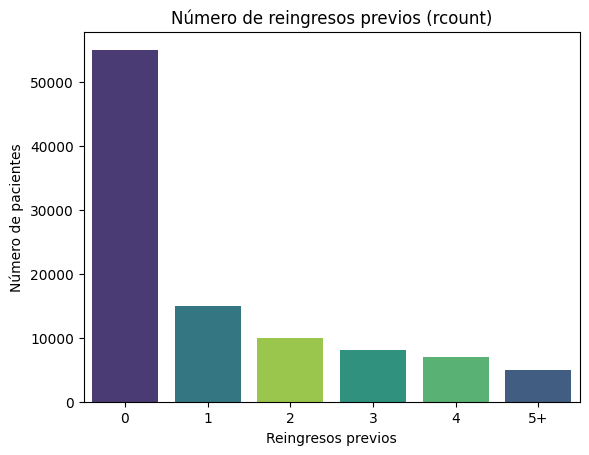

In [7]:
# Gráfico de barras: número de reingresos (rcount) ordenado
orden_rcount = ["0", "1", "2", "3", "4", "5+"]
sns.countplot(x='rcount', data=df_filtered, order=orden_rcount, hue='rcount', palette='viridis', legend=False)
plt.title("Número de reingresos previos (rcount)")
plt.xlabel("Reingresos previos")
plt.ylabel("Número de pacientes")
plt.show()

/tmp/ipykernel_59110/1169527766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df_filtered, palette='pastel')


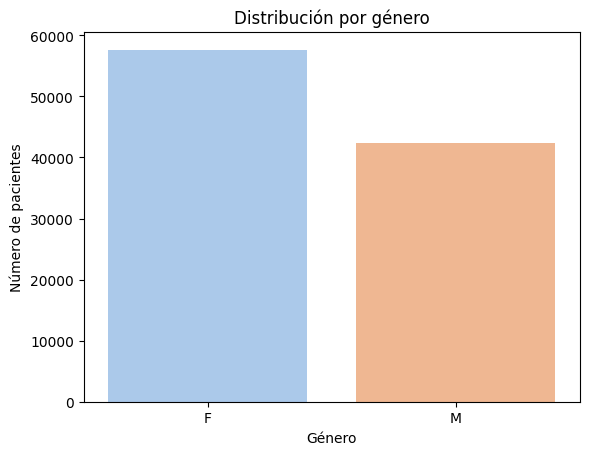

In [6]:
# Gráfico de barras: género
sns.countplot(x='gender', data=df_filtered, palette='pastel')
plt.title("Distribución por género")
plt.xlabel("Género")
plt.ylabel("Número de pacientes")
plt.show()

### Interpretación  

Observamos una ligera mayoría de pacientes hombres en los datos analizados.  
La distribución por género no es exactamente equilibrada (aproximadamente 58% hombres frente a 42% mujeres), pero esta diferencia no representa un problema significativo, ya que contamos con un volumen muy amplio de datos.  
Al tratarse de una variable categórica, no requiere un análisis mucho más profundo en este punto, aunque es importante tenerla en cuenta para futuras comparaciones o posibles sesgos en los modelos.  


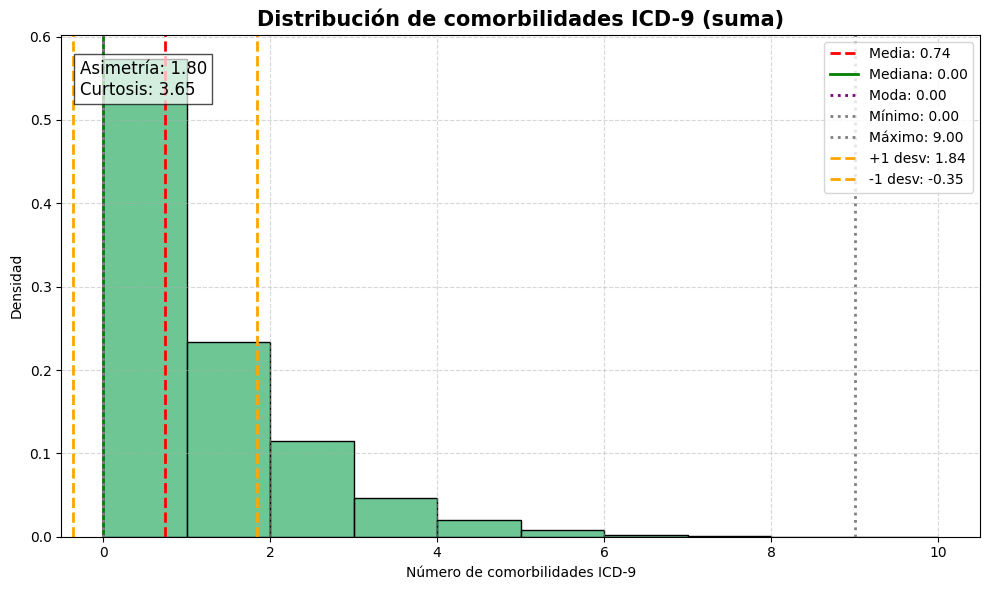

Media: 0.74
Mediana: 0.00
Moda: 0.00
Mínimo: 0.00
Máximo: 9.00
Desviación estándar: 1.10
Asimetría: 1.80
Curtosis: 3.65


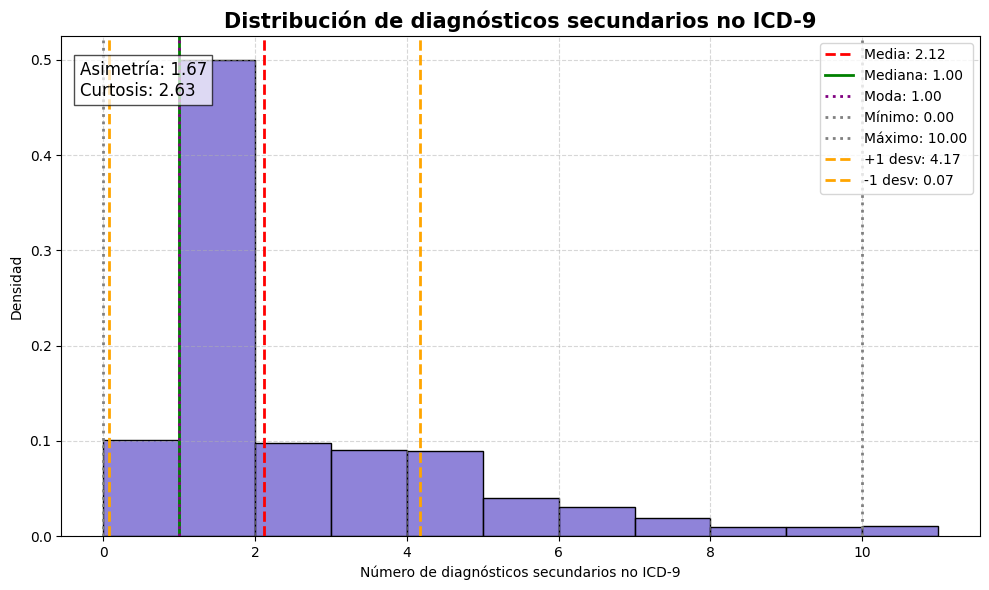

Media: 2.12
Mediana: 1.00
Moda: 1.00
Mínimo: 0.00
Máximo: 10.00
Desviación estándar: 2.05
Asimetría: 1.67
Curtosis: 2.63


In [7]:
# Histograma y estadísticas descriptivas para Comorbilidades ICD-9 (suma)

icd9_sum = df_filtered['icd9_comorbidity_sum'].dropna().values

media_icd9 = np.mean(icd9_sum)
mediana_icd9 = np.median(icd9_sum)
moda_icd9 = stats.mode(icd9_sum, keepdims=True).mode[0]
minimo_icd9 = np.min(icd9_sum)
maximo_icd9 = np.max(icd9_sum)
desviacion_icd9 = np.std(icd9_sum)
asimetria_icd9 = stats.skew(icd9_sum)
curtosis_icd9 = stats.kurtosis(icd9_sum)

plt.figure(figsize=(10, 6))
sns.histplot(icd9_sum, bins=range(int(minimo_icd9), int(maximo_icd9)+2), kde=False, color='mediumseagreen', edgecolor='black', stat='density')
plt.axvline(media_icd9, color='red', linestyle='--', linewidth=2, label=f'Media: {media_icd9:.2f}')
plt.axvline(mediana_icd9, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_icd9:.2f}')
plt.axvline(moda_icd9, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_icd9:.2f}')
plt.axvline(minimo_icd9, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_icd9:.2f}')
plt.axvline(maximo_icd9, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_icd9:.2f}')
plt.axvline(media_icd9 + desviacion_icd9, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_icd9+desviacion_icd9):.2f}')
plt.axvline(media_icd9 - desviacion_icd9, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_icd9-desviacion_icd9):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_icd9:.2f}\nCurtosis: {curtosis_icd9:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución de comorbilidades ICD-9 (suma)", fontsize=15, weight="bold")
plt.xlabel("Número de comorbilidades ICD-9")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_icd9:.2f}")
print(f"Mediana: {mediana_icd9:.2f}")
print(f"Moda: {moda_icd9:.2f}")
print(f"Mínimo: {minimo_icd9:.2f}")
print(f"Máximo: {maximo_icd9:.2f}")
print(f"Desviación estándar: {desviacion_icd9:.2f}")
print(f"Asimetría: {asimetria_icd9:.2f}")
print(f"Curtosis: {curtosis_icd9:.2f}")

# Histograma para diagnósticos secundarios ICD-9
sec_diag = df_filtered['secondarydiagnosisnonicd9'].dropna().values

media_sec = np.mean(sec_diag)
mediana_sec = np.median(sec_diag)
moda_sec = stats.mode(sec_diag, keepdims=True).mode[0]
minimo_sec = np.min(sec_diag)
maximo_sec = np.max(sec_diag)
desviacion_sec = np.std(sec_diag)
asimetria_sec = stats.skew(sec_diag)
curtosis_sec = stats.kurtosis(sec_diag)

plt.figure(figsize=(10, 6))
sns.histplot(sec_diag, bins=range(int(minimo_sec), int(maximo_sec)+2), kde=False, color='slateblue', edgecolor='black', stat='density')
plt.axvline(media_sec, color='red', linestyle='--', linewidth=2, label=f'Media: {media_sec:.2f}')
plt.axvline(mediana_sec, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_sec:.2f}')
plt.axvline(moda_sec, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_sec:.2f}')
plt.axvline(minimo_sec, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_sec:.2f}')
plt.axvline(maximo_sec, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_sec:.2f}')
plt.axvline(media_sec + desviacion_sec, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_sec+desviacion_sec):.2f}')
plt.axvline(media_sec - desviacion_sec, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_sec-desviacion_sec):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_sec:.2f}\nCurtosis: {curtosis_sec:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución de diagnósticos secundarios no ICD-9", fontsize=15, weight="bold")
plt.xlabel("Número de diagnósticos secundarios no ICD-9")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_sec:.2f}")
print(f"Mediana: {mediana_sec:.2f}")
print(f"Moda: {moda_sec:.2f}")
print(f"Mínimo: {minimo_sec:.2f}")
print(f"Máximo: {maximo_sec:.2f}")
print(f"Desviación estándar: {desviacion_sec:.2f}")
print(f"Asimetría: {asimetria_sec:.2f}")
print(f"Curtosis: {curtosis_sec:.2f}")

### Interpretación

En la primera gráfica, correspondiente a la **suma de comorbilidades ICD-9**, observamos una distribución muy asimétrica hacia la derecha (asimetría = 1.80), con la gran mayoría de los pacientes concentrados en valores bajos (0 o 1 comorbilidad).  
La curtosis elevada (3.65) indica la presencia de colas más pesadas de lo esperado en una distribución normal, lo que confirma que existen algunos casos extremos con un número relativamente alto de comorbilidades, aunque son poco frecuentes.  
En resumen, la mayoría de los pacientes presenta pocas comorbilidades relevantes, pero existe un pequeño grupo con mayor carga clínica que puede tener un impacto significativo en la duración de la estancia hospitalaria.

En la segunda gráfica, que muestra la distribución de **diagnósticos secundarios no ICD-9**, se aprecia un patrón similar: fuerte asimetría positiva (1.67) y curtosis también elevada (2.63).  
La mayoría de los pacientes tiene entre 0 y 2 diagnósticos secundarios, pero hay casos aislados que alcanzan hasta 10. Estos valores extremos sugieren la existencia de pacientes más complejos y con mayor riesgo clínico.  

En conjunto, ambas variables reflejan la heterogeneidad clínica de los pacientes: mientras la mayoría presenta pocas condiciones adicionales, los casos con múltiples comorbilidades o diagnósticos secundarios pueden jugar un papel clave en la predicción de la duración de la hospitalización.


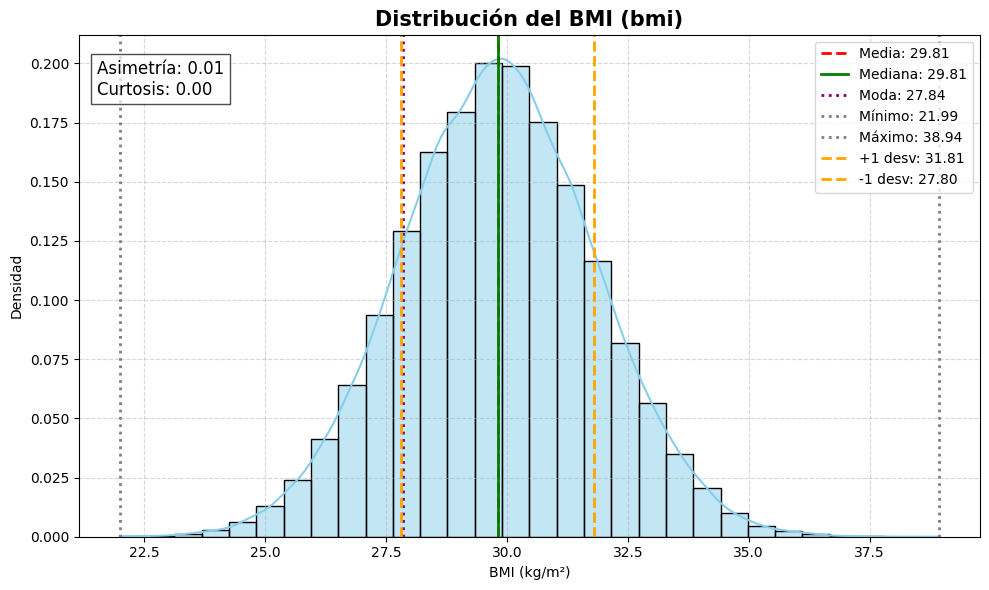

Media: 29.81
Mediana: 29.81
Moda: 27.84
Mínimo: 21.99
Máximo: 38.94
Desviación estándar: 2.00
Asimetría: 0.01
Curtosis: 0.00


In [8]:
# Histograma y estadísticas descriptivas para BMI

bmi = df_filtered['bmi'].dropna().values

# Cálculos estadísticos
media_bmi = np.mean(bmi)
mediana_bmi = np.median(bmi)
moda_bmi = stats.mode(bmi, keepdims=True).mode[0]
minimo_bmi = np.min(bmi)
maximo_bmi = np.max(bmi)
desviacion_bmi = np.std(bmi)
asimetria_bmi = stats.skew(bmi)
curtosis_bmi = stats.kurtosis(bmi)

# Histograma con KDE
plt.figure(figsize=(10, 6))
sns.histplot(bmi, bins=30, kde=True, color='skyblue', stat='density', edgecolor='black')
plt.axvline(media_bmi, color='red', linestyle='--', linewidth=2, label=f'Media: {media_bmi:.2f}')
plt.axvline(mediana_bmi, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_bmi:.2f}')
plt.axvline(moda_bmi, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_bmi:.2f}')
plt.axvline(minimo_bmi, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_bmi:.2f}')
plt.axvline(maximo_bmi, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_bmi:.2f}')
plt.axvline(media_bmi + desviacion_bmi, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_bmi+desviacion_bmi):.2f}')
plt.axvline(media_bmi - desviacion_bmi, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_bmi-desviacion_bmi):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_bmi:.2f}\nCurtosis: {curtosis_bmi:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución del BMI (bmi)", fontsize=15, weight="bold")
plt.xlabel("BMI (kg/m²)")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_bmi:.2f}")
print(f"Mediana: {mediana_bmi:.2f}")
print(f"Moda: {moda_bmi:.2f}")
print(f"Mínimo: {minimo_bmi:.2f}")
print(f"Máximo: {maximo_bmi:.2f}")
print(f"Desviación estándar: {desviacion_bmi:.2f}")
print(f"Asimetría: {asimetria_bmi:.2f}")
print(f"Curtosis: {curtosis_bmi:.2f}")


### Interpretación

Según la asimetría y la curtosis, la distribución del IMC (BMI) es bastante cercana a una distribución normal y simétrica. La media se sitúa alrededor de 29,8, un valor elevado si consideramos que un IMC saludable está entre 19 y 25. Sin embargo, esto es coherente con la realidad de la población estadounidense, donde estudios recientes (2020) reportan un IMC medio cercano a 30.

La desviación estándar es relativamente baja en comparación con la media, lo que indica que la mayoría de los valores no se alejan mucho del promedio. No obstante, el rango observado (aproximadamente de 22 a 39) muestra la presencia de valores extremos, tanto por debajo como por encima de la media. Estos valores extremos pueden estar asociados a casos de desnutrición o de obesidad severa, condiciones que, según la literatura, suelen estar relacionadas con estancias hospitalarias más prolongadas.

En resumen, la distribución del IMC en este conjunto de datos refleja la tendencia de la población general, con una mayoría de pacientes en rangos de sobrepeso u obesidad, y algunos casos extremos que podrían influir en la duración de la estancia hospitalaria.œ

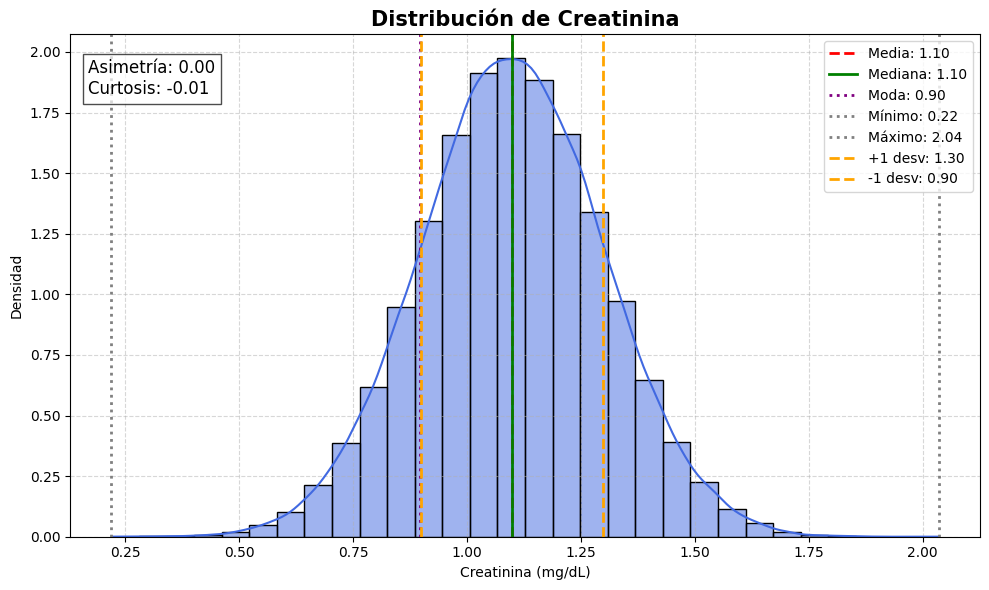

Media: 1.10
Mediana: 1.10
Moda: 0.90
Mínimo: 0.22
Máximo: 2.04
Desviación estándar: 0.20
Asimetría: 0.00
Curtosis: -0.01


In [10]:
# Histograma y estadísticas descriptivas para Creatinina

creatinina = df_filtered['creatinine'].dropna().values

# Cálculos estadísticos
media_creat = np.mean(creatinina)
mediana_creat = np.median(creatinina)
moda_creat = stats.mode(creatinina, keepdims=True).mode[0]
minimo_creat = np.min(creatinina)
maximo_creat = np.max(creatinina)
desviacion_creat = np.std(creatinina)
asimetria_creat = stats.skew(creatinina)
curtosis_creat = stats.kurtosis(creatinina)

# Histograma con KDE
plt.figure(figsize=(10, 6))
sns.histplot(creatinina, bins=30, kde=True, color='royalblue', stat='density', edgecolor='black')
plt.axvline(media_creat, color='red', linestyle='--', linewidth=2, label=f'Media: {media_creat:.2f}')
plt.axvline(mediana_creat, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_creat:.2f}')
plt.axvline(moda_creat, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_creat:.2f}')
plt.axvline(minimo_creat, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_creat:.2f}')
plt.axvline(maximo_creat, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_creat:.2f}')
plt.axvline(media_creat + desviacion_creat, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_creat+desviacion_creat):.2f}')
plt.axvline(media_creat - desviacion_creat, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_creat-desviacion_creat):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_creat:.2f}\nCurtosis: {curtosis_creat:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución de Creatinina", fontsize=15, weight="bold")
plt.xlabel("Creatinina (mg/dL)")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_creat:.2f}")
print(f"Mediana: {mediana_creat:.2f}")
print(f"Moda: {moda_creat:.2f}")
print(f"Mínimo: {minimo_creat:.2f}")
print(f"Máximo: {maximo_creat:.2f}")
print(f"Desviación estándar: {desviacion_creat:.2f}")
print(f"Asimetría: {asimetria_creat:.2f}")
print(f"Curtosis: {curtosis_creat:.2f}")

### Interpretación  

La distribución de la creatinina muestra un comportamiento muy cercano a una distribución normal. La media (1.10), la mediana (1.10) y la moda (0.90) están muy próximas entre sí, lo que indica simetría en torno al valor central. Además, la asimetría reportada es prácticamente nula (0.00) y la curtosis (-0.01) se encuentra muy cercana a la de una distribución normal, lo que confirma la ausencia de sesgos significativos y de colas excesivamente pesadas.  

La desviación estándar (0.20) es baja en relación con la media, lo que refleja que la mayoría de los valores se concentran en un rango estrecho, entre aproximadamente 0.9 y 1.3 mg/dL. El rango observado (0.22 a 2.04 mg/dL) incluye algunos valores más extremos, pero estos no afectan de manera relevante la forma global de la distribución.  

En resumen, los datos de creatinina presentan una distribución aproximadamente normal, simétrica y con una variabilidad reducida, lo que sugiere que la mayoría de los individuos se encuentran en rangos fisiológicos estables y sin la influencia de valores atípicos extremos.  


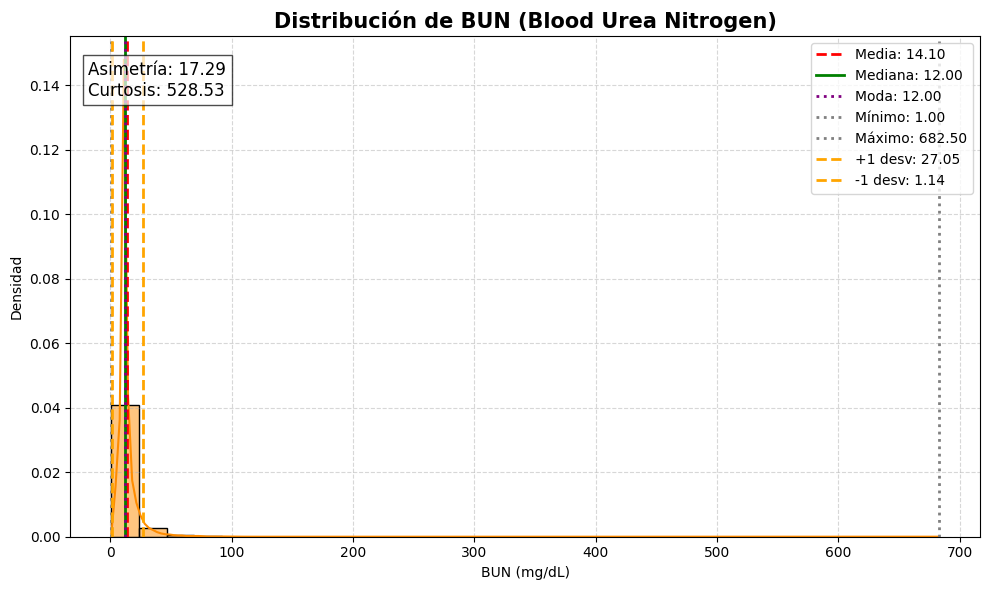

Media: 14.10
Mediana: 12.00
Moda: 12.00
Mínimo: 1.00
Máximo: 682.50
Desviación estándar: 12.95
Asimetría: 17.29
Curtosis: 528.53


In [5]:
bun = df_filtered['bloodureanitro'].dropna().values

# estadísticos
media_bun = np.mean(bun)
mediana_bun = np.median(bun)
moda_bun = stats.mode(bun, keepdims=True).mode[0]
minimo_bun = np.min(bun)
maximo_bun = np.max(bun)
desviacion_bun = np.std(bun)
asimetria_bun = stats.skew(bun)
curtosis_bun = stats.kurtosis(bun)

plt.figure(figsize=(10, 6))
sns.histplot(bun, bins=30, kde=True, color='darkorange', stat='density', edgecolor='black')
plt.axvline(media_bun, color='red', linestyle='--', linewidth=2, label=f'Media: {media_bun:.2f}')
plt.axvline(mediana_bun, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_bun:.2f}')
plt.axvline(moda_bun, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_bun:.2f}')
plt.axvline(minimo_bun, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_bun:.2f}')
plt.axvline(maximo_bun, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_bun:.2f}')
plt.axvline(media_bun + desviacion_bun, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_bun+desviacion_bun):.2f}')
plt.axvline(media_bun - desviacion_bun, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_bun-desviacion_bun):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_bun:.2f}\nCurtosis: {curtosis_bun:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución de BUN (Blood Urea Nitrogen)", fontsize=15, weight="bold")
plt.xlabel("BUN (mg/dL)")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_bun:.2f}")
print(f"Mediana: {mediana_bun:.2f}")
print(f"Moda: {moda_bun:.2f}")
print(f"Mínimo: {minimo_bun:.2f}")
print(f"Máximo: {maximo_bun:.2f}")
print(f"Desviación estándar: {desviacion_bun:.2f}")
print(f"Asimetría: {asimetria_bun:.2f}")
print(f"Curtosis: {curtosis_bun:.2f}")

### Interpretación  

Según los estadísticos descriptivos, la distribución del BUN (Blood Urea Nitrogen) parece concentrarse en torno a valores bajos, con una media de 14.1 y una mediana de 12, lo que sugiere que la mayoría de los pacientes presentan niveles dentro de un rango relativamente normal. Sin embargo, la asimetría extremadamente alta (17.29) y la curtosis excesiva (528.53) indican que la distribución está fuertemente sesgada hacia la derecha y presenta colas muy pesadas. Esto significa que existen valores atípicos muy elevados, como el máximo de 682.5 mg/dL, que distorsionan notablemente la forma de la curva. La desviación estándar (12.95) es moderada en comparación con la media, lo que confirma que la variabilidad central no es excesiva, pero la dispersión hacia valores altos resulta desproporcionada.  

En resumen, aunque la mayor parte de los casos se concentran alrededor de 12–14 mg/dL, la presencia de outliers extremos genera una distribución no normal, con sesgo positivo marcado y curtosis muy elevada, lo que debe ser considerado cuidadosamente en cualquier análisis estadístico posterior.  


## III.B - Bivariadas

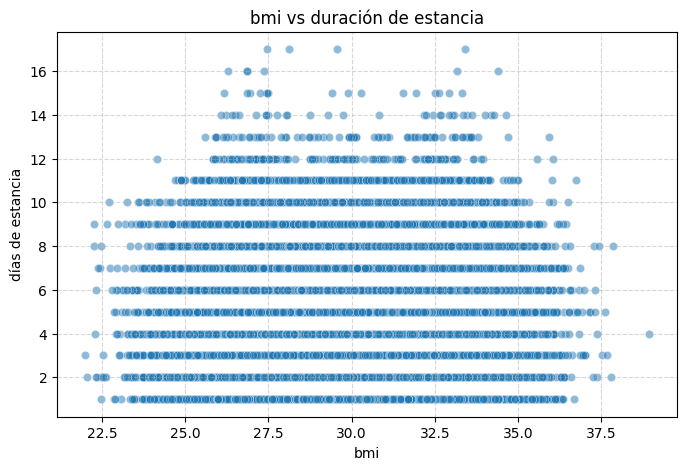

correlación pearson: 0.00
correlación spearman: -0.00


In [12]:
# dispersión entre bmi y duración de estancia
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='lengthofstay', data=df_filtered, alpha=0.5)
plt.title("bmi vs duración de estancia")
plt.xlabel("bmi")
plt.ylabel("días de estancia")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# correlación pearson y spearman
pearson = df_filtered[['bmi', 'lengthofstay']].corr(method='pearson').iloc[0,1]
spearman = df_filtered[['bmi', 'lengthofstay']].corr(method='spearman').iloc[0,1]
print(f"correlación pearson: {pearson:.2f}")
print(f"correlación spearman: {spearman:.2f}")

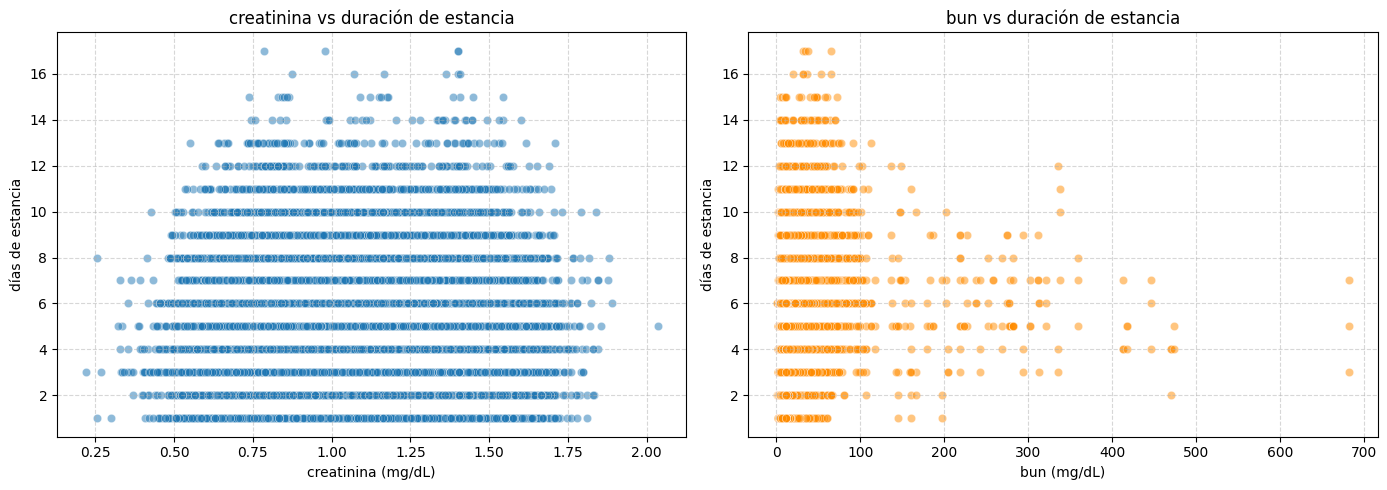

creatinina - correlación pearson: -0.00, spearman: -0.00
bun - correlación pearson: 0.15, spearman: 0.12


In [14]:
# relación entre creatinina y duración de estancia, y entre bun y duración de estancia

fig, axs = plt.subplots(1, 2, figsize=(14,5))

# creatinina vs duración de estancia
sns.scatterplot(x='creatinine', y='lengthofstay', data=df_filtered, alpha=0.5, ax=axs[0])
axs[0].set_title("creatinina vs duración de estancia")
axs[0].set_xlabel("creatinina (mg/dL)")
axs[0].set_ylabel("días de estancia")
axs[0].grid(True, linestyle='--', alpha=0.5)

# bun vs duración de estancia
sns.scatterplot(x='bloodureanitro', y='lengthofstay', data=df_filtered, alpha=0.5, ax=axs[1], color='darkorange')
axs[1].set_title("bun vs duración de estancia")
axs[1].set_xlabel("bun (mg/dL)")
axs[1].set_ylabel("días de estancia")
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# correlaciones
pearson_creat = df_filtered[['creatinine', 'lengthofstay']].corr(method='pearson').iloc[0,1]
spearman_creat = df_filtered[['creatinine', 'lengthofstay']].corr(method='spearman').iloc[0,1]
pearson_bun = df_filtered[['bloodureanitro', 'lengthofstay']].corr(method='pearson').iloc[0,1]
spearman_bun = df_filtered[['bloodureanitro', 'lengthofstay']].corr(method='spearman').iloc[0,1]

print(f"creatinina - correlación pearson: {pearson_creat:.2f}, spearman: {spearman_creat:.2f}")
print(f"bun - correlación pearson: {pearson_bun:.2f}, spearman: {spearman_bun:.2f}")

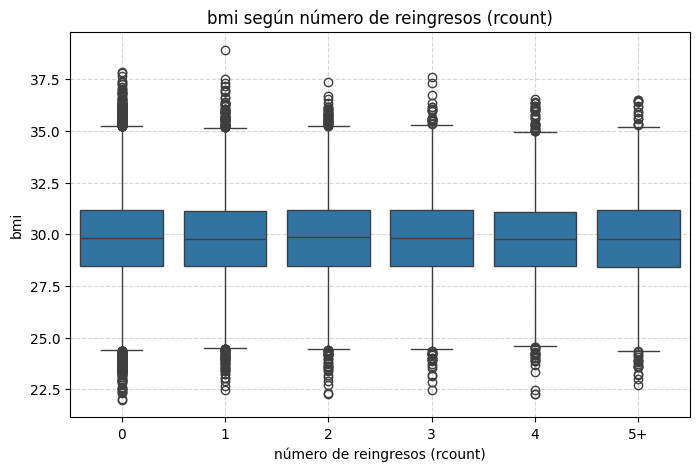

In [21]:
# boxplot de bmi según número de reingresos (rcount)
plt.figure(figsize=(8,5))
orden_rcount = ["0", "1", "2", "3", "4", "5+"]
sns.boxplot(x='rcount', y='bmi', data=df_filtered,order=orden_rcount)
plt.title("bmi según número de reingresos (rcount)")
plt.xlabel("número de reingresos (rcount)")
plt.ylabel("bmi")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

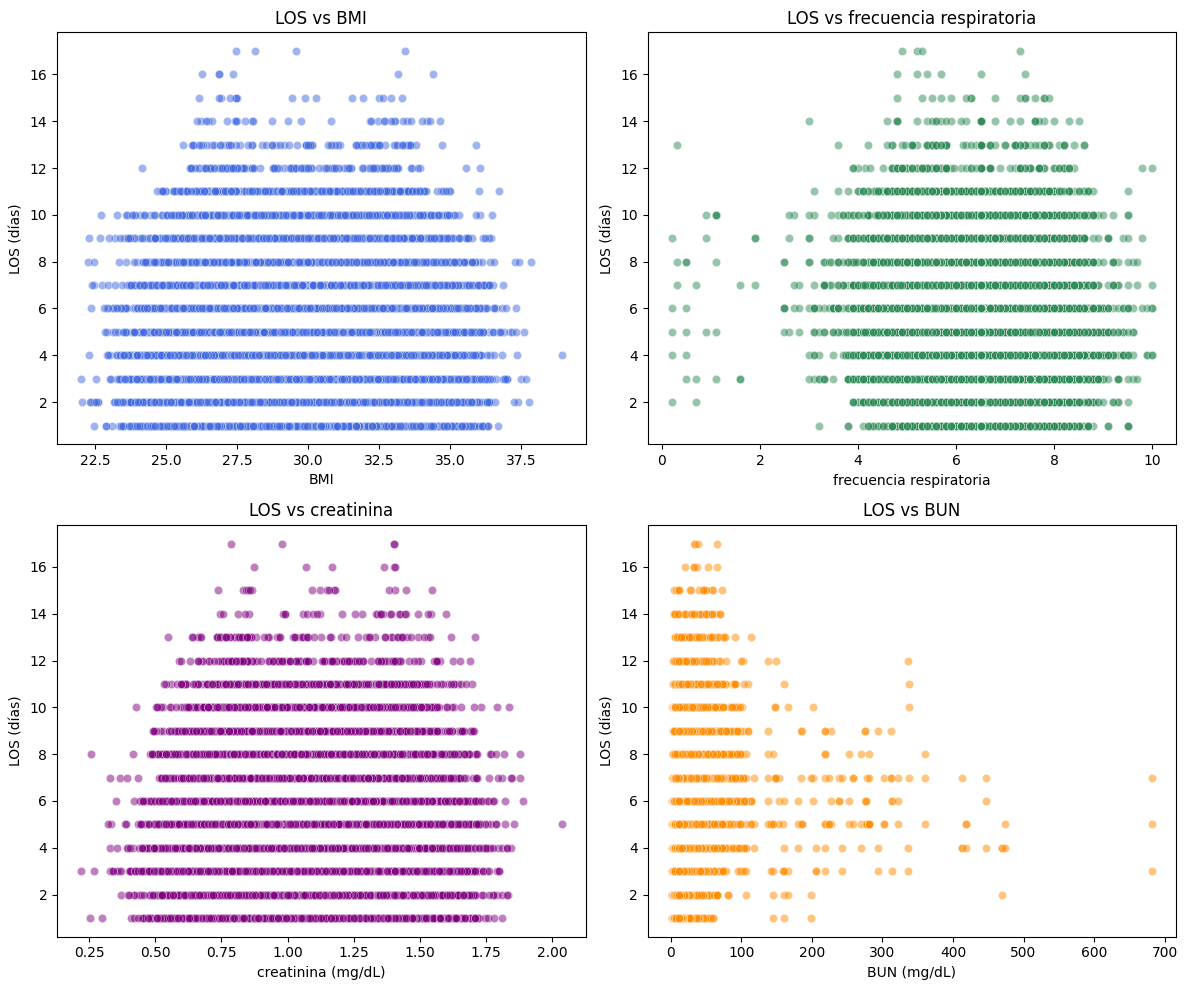

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# scatterplot los vs bmi (azul)
sns.scatterplot(x="bmi", y="lengthofstay", data=df_filtered, ax=axes[0, 0], alpha=0.5, color="royalblue")
axes[0, 0].set_title("LOS vs BMI")
axes[0, 0].set_xlabel("BMI")
axes[0, 0].set_ylabel("LOS (días)")

# scatterplot los vs frecuencia respiratoria (verde)
sns.scatterplot(x="respiration", y="lengthofstay", data=df_filtered, ax=axes[0, 1], alpha=0.5, color="seagreen")
axes[0, 1].set_title("LOS vs frecuencia respiratoria")
axes[0, 1].set_xlabel("frecuencia respiratoria")
axes[0, 1].set_ylabel("LOS (días)")

# scatterplot los vs creatinina (violeta)
sns.scatterplot(x="creatinine", y="lengthofstay", data=df_filtered, ax=axes[1, 0], alpha=0.5, color="purple")
axes[1, 0].set_title("LOS vs creatinina")
axes[1, 0].set_xlabel("creatinina (mg/dL)")
axes[1, 0].set_ylabel("LOS (días)")

# scatterplot los vs bun (naranja)
sns.scatterplot(x="bloodureanitro", y="lengthofstay", data=df_filtered, ax=axes[1, 1], alpha=0.5, color="darkorange")
axes[1, 1].set_title("LOS vs BUN")
axes[1, 1].set_xlabel("BUN (mg/dL)")
axes[1, 1].set_ylabel("LOS (días)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_59110/620833128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='lengthofstay', data=df_filtered, palette='pastel')


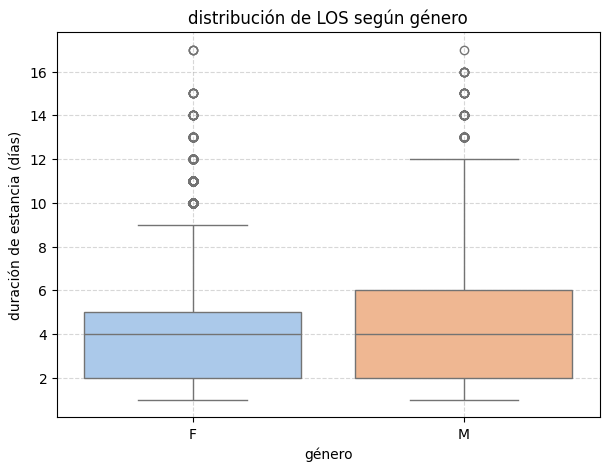

/tmp/ipykernel_59110/620833128.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rcount', y='lengthofstay', data=df_filtered, order=orden_rcount, palette='viridis')


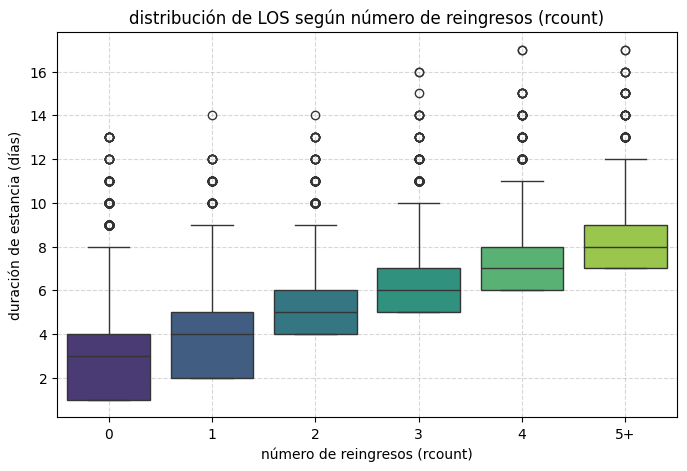

In [31]:
# boxplot de la durée de séjour (lengthofstay) selon le genre
plt.figure(figsize=(7,5))
sns.boxplot(x='gender', y='lengthofstay', data=df_filtered, palette='pastel')
plt.title('distribución de LOS según género')
plt.xlabel('género')
plt.ylabel('duración de estancia (días)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# boxplot de la durée de séjour selon le nombre de réadmissions (rcount)
plt.figure(figsize=(8,5))
orden_rcount = ["0", "1", "2", "3", "4", "5+"]
sns.boxplot(x='rcount', y='lengthofstay', data=df_filtered, order=orden_rcount, palette='viridis')
plt.title('distribución de LOS según número de reingresos (rcount)')
plt.xlabel('número de reingresos (rcount)')
plt.ylabel('duración de estancia (días)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Interpretación  

El gráfico muestra una relación clara entre el número de reingresos (**rcount**) y la duración de la estancia hospitalaria (**LOS**). En general, a medida que aumenta el número de reingresos, la mediana de los días de hospitalización también se incrementa.  

Los pacientes que no presentan reingresos (rcount = 0) tienen estancias cortas, con una mediana cercana a los 3 días. En cambio, aquellos con 1 o 2 reingresos ya presentan estancias más largas (4 a 6 días). A partir de 3 y especialmente en las categorías de 4 y 5+, se observa un aumento progresivo, alcanzando medianas de entre 7 y 8 días, además de una mayor dispersión en los valores.  

Otro aspecto relevante es la presencia de **valores atípicos en la parte superior de la distribución**, es decir, pacientes con estancias hospitalarias muy largas en todas las categorías. En cambio, no se observan valores extremos por debajo, lo que indica que el límite inferior de los días de estancia es más estable mientras que el superior varía considerablemente.


## III.C - Multivariadas

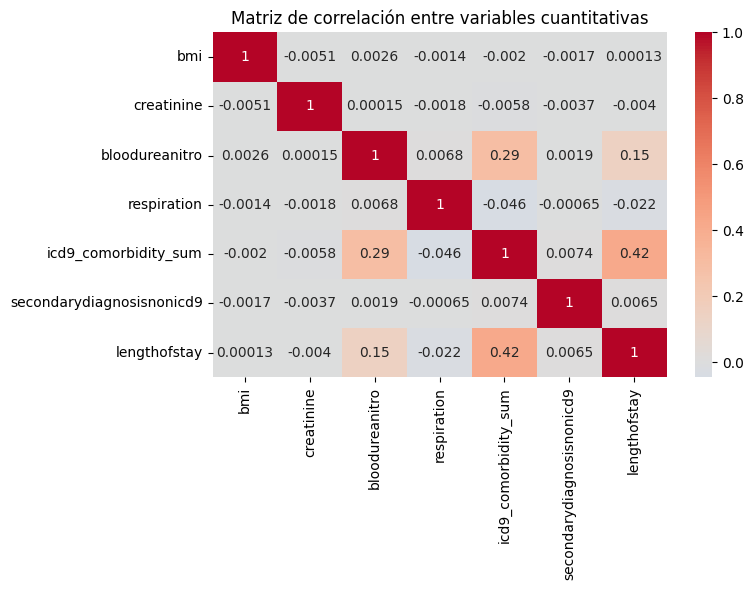


Matriz de autovectores (componentes principales):
                                CP1       CP2
bmi                        0.001841 -0.565549
creatinine                -0.013118  0.753846
bloodureanitro             0.699229 -0.005300
respiration               -0.094792 -0.151418
icd9_comorbidity_sum       0.708099  0.009940
secondarydiagnosisnonicd9  0.022668 -0.298022


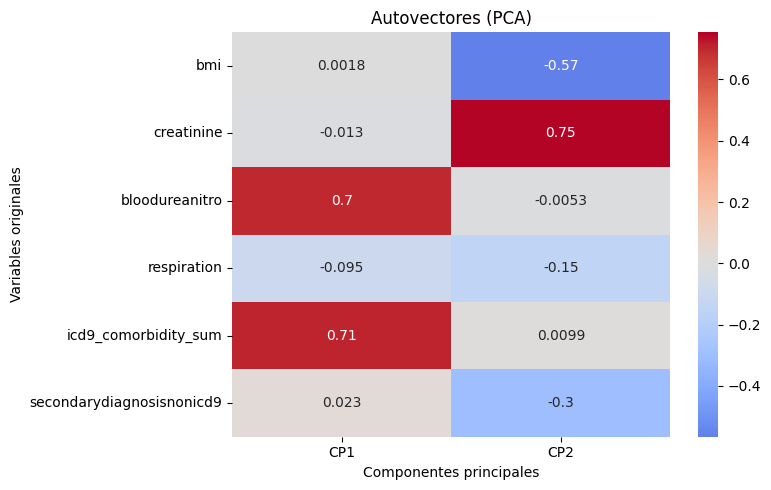


Varianza explicada:
CP1: 21.60%
CP2: 16.76%
Varianza total explicada por CP1 y CP2: 38.36%


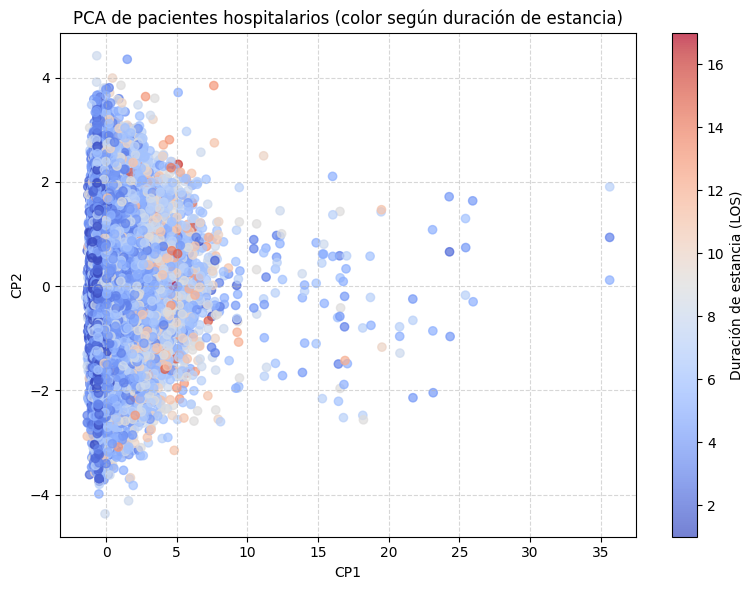

In [27]:
# Matriz de correlación entre variables cuantitativas
plt.figure(figsize=(8,6))
corr = df_filtered[['bmi', 'creatinine', 'bloodureanitro', 'respiration', 'icd9_comorbidity_sum', 'secondarydiagnosisnonicd9', 'lengthofstay']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables cuantitativas')
plt.tight_layout()
plt.show()

# PCA sin la variable objetivo
vars_pca = ['bmi', 'creatinine', 'bloodureanitro', 'respiration', 'icd9_comorbidity_sum', 'secondarydiagnosisnonicd9']
df_pca = df_filtered.dropna(subset=vars_pca + ['lengthofstay'])

# Estandarización
X_std = StandardScaler().fit_transform(df_pca[vars_pca])

# PCA
pca = PCA(n_components=2)
comps = pca.fit_transform(X_std)

# Matriz de autovectores (componentes principales)
comps_df = pd.DataFrame(pca.components_.T, columns=['CP1', 'CP2'], index=vars_pca)
print("\nMatriz de autovectores (componentes principales):")
print(comps_df)

plt.figure(figsize=(8, 5))
sns.heatmap(comps_df, annot=True, cmap='coolwarm', center=0)
plt.title('Autovectores (PCA)')
plt.ylabel('Variables originales')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

# Varianza explicada
var_exp = pca.explained_variance_ratio_
print("\nVarianza explicada:")
for i, v in enumerate(var_exp):
    print(f"CP{i+1}: {v*100:.2f}%")
print(f"Varianza total explicada por CP1 y CP2: {var_exp.sum()*100:.2f}%")

# Proyección de los individuos, coloreada por duración de estancia (LOS)
plt.figure(figsize=(8,6))
scatter = plt.scatter(comps[:,0], comps[:,1], c=df_pca['lengthofstay'], cmap='coolwarm', alpha=0.7)
plt.xlabel("CP1")
plt.ylabel("CP2")
plt.title("PCA de pacientes hospitalarios (color según duración de estancia)")
cbar = plt.colorbar(scatter)
cbar.set_label("Duración de estancia (LOS)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()